## Week 9 — Neural Network + MC Dropout EI + Interior Penalty (6D), 39 samples

**Approach**: Train a compact neural network surrogate (6→5→5→1), compute Expected Improvement via MC Dropout (50 stochastic forward passes), and apply a multiplicative interior penalty to discourage boundary-hugging candidates. Since all F7 outputs are positive (EI ≥ 0, w ∈ [0.01, 1.0]), multiplicative `penalised_EI = EI × w(x)` works correctly.

**Enhancements (Week 9)**: Three-colour visualisation (blue=initial, orange=submissions, green★=proposed), quantitative performance evaluation (convergence metrics with stalling detection, exploration spread, LOO surrogate error, strategy interpretation).

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Architecture | 6→5→5→1 (2L×5N) | Compact for 39 samples (71 params) |
| Learning rate | 0.005 | Moderate for Adam on small network |
| Dropout | 0.1 | 5-node layers can't afford 20% capacity loss |
| Epochs | 200 | 71 params converge fast; longer risks memorisation |
| MC samples | 50 | Sufficient for EI ranking |
| Candidates | 20,000 | Good coverage in 6D |
| STEEPNESS | 0.1 | 6D product already strong; gentle per-dim decay |
| FLOOR | 0.01 | Prevents zero-weight at boundaries |

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
from itertools import groupby
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore', category=RuntimeWarning)

In [14]:
# ── Constants ──
LEARNING_RATE  = 0.005
EPOCHS         = 200
DROPOUT        = 0.1
MC_SAMPLES     = 50
N_CANDIDATES   = 20_000
STEEPNESS      = 0.1
FLOOR          = 0.01
DIM            = 6
GRID_RES       = 50

# ── Dataset constants ──
N_INITIAL      = 30
N_TOTAL        = 39
N_DIMS         = 6
N_SUBMISSIONS  = N_TOTAL - N_INITIAL  # 9

# ── Stalling detection ──
STALLING_CONSECUTIVE_THRESHOLD = 3
STALLING_RELATIVE_THRESHOLD    = 0.05

hyperparam_names = ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']

print("Constants configured:")
print(f"  DIM={DIM}, LEARNING_RATE={LEARNING_RATE}, EPOCHS={EPOCHS}, DROPOUT={DROPOUT}")
print(f"  MC_SAMPLES={MC_SAMPLES}, N_CANDIDATES={N_CANDIDATES:,}")
print(f"  STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"  N_INITIAL={N_INITIAL}, N_TOTAL={N_TOTAL}, N_SUBMISSIONS={N_SUBMISSIONS}")
print(f"  Stalling: consecutive>={STALLING_CONSECUTIVE_THRESHOLD} or relative<{STALLING_RELATIVE_THRESHOLD}")
print(f"  Hyperparams: {hyperparam_names}")

Constants configured:
  DIM=6, LEARNING_RATE=0.005, EPOCHS=200, DROPOUT=0.1
  MC_SAMPLES=50, N_CANDIDATES=20,000
  STEEPNESS=0.1, FLOOR=0.01
  N_INITIAL=30, N_TOTAL=39, N_SUBMISSIONS=9
  Stalling: consecutive>=3 or relative<0.05
  Hyperparams: ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']


In [15]:
# ── Data Loading & Z-Score Normalisation (Week 9) ──
X_raw = np.load('../../data/f7/updated_inputs - Week 9.npy')
y_raw = np.load('../../data/f7/updated_outputs - Week 9.npy')

assert X_raw.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "All inputs must be in [0, 1]"
assert not np.any(np.isnan(y_raw)), "No NaN outputs allowed"
assert np.all(y_raw > 0), "All F7 outputs should be positive"

# Split initial vs submissions
X_initial, y_initial = X_raw[:N_INITIAL], y_raw[:N_INITIAL]
X_submissions, y_submissions = X_raw[N_INITIAL:], y_raw[N_INITIAL:]

# Z-score normalisation
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-8

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

# Torch tensors for NN training
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

print(f"Week 9 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"  Initial samples: {N_INITIAL}, Submissions: {N_SUBMISSIONS}")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed: {y_raw.max():.6f} at sample {y_raw.argmax()} ({X_raw[y_raw.argmax()]})")
print(f"\nDimensions: {', '.join(hyperparam_names)}")
print(f"Normalisation: X_mean={np.round(X_mean, 4)}, X_std={np.round(X_std, 4)}")
print(f"               y_mean={y_mean:.6f}, y_std={y_std:.6f}")

# Per-dimension ranges
print(f"\nPer-dimension ranges:")
for i, name in enumerate(hyperparam_names):
    lo, hi = X_raw[:, i].min(), X_raw[:, i].max()
    print(f"  x{i} ({name:>14s}): [{lo:.6f}, {hi:.6f}]")

Week 9 Data: 39 samples, 6 dimensions
  Initial samples: 30, Submissions: 9
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at sample 33 ([0.       0.261823 0.623526 0.173633 0.3524   0.687293])

Dimensions: learning_rate, reg_strength, n_layers, dropout, batch_size, optimizer
Normalisation: X_mean=[0.4239 0.404  0.4271 0.4562 0.4487 0.523 ], X_std=[0.3215 0.2464 0.2914 0.3016 0.2841 0.2537]
               y_mean=0.421412, y_std=0.564170

Per-dimension ranges:
  x0 ( learning_rate): [0.000000, 0.942451]
  x1 (  reg_strength): [0.011813, 0.924694]
  x2 (      n_layers): [0.003635, 0.980389]
  x3 (       dropout): [0.036612, 0.961017]
  x4 (    batch_size): [0.014944, 0.998655]
  x5 (     optimizer): [0.051100, 0.951014]


### Neural Network Surrogate — 6→5→5→1 (carried from Week 8)

- **Architecture**: `SurrogateNN` — 2 hidden layers of 5 neurons each (71 parameters)
- **Activation**: ReLU + Dropout(0.1) after each hidden layer
- **Optimiser**: Adam(lr=0.005), MSE loss, 200 epochs
- **Seed**: `torch.manual_seed(42)` for reproducibility
- **R² validation**: Computed on original (un-normalised) scale

Architecture: 6→5→5→1, Parameters: 71
  Epoch 40/200, Loss: 0.685372
  Epoch 80/200, Loss: 0.667056
  Epoch 120/200, Loss: 0.506256
  Epoch 160/200, Loss: 0.456758
  Epoch 200/200, Loss: 0.304953


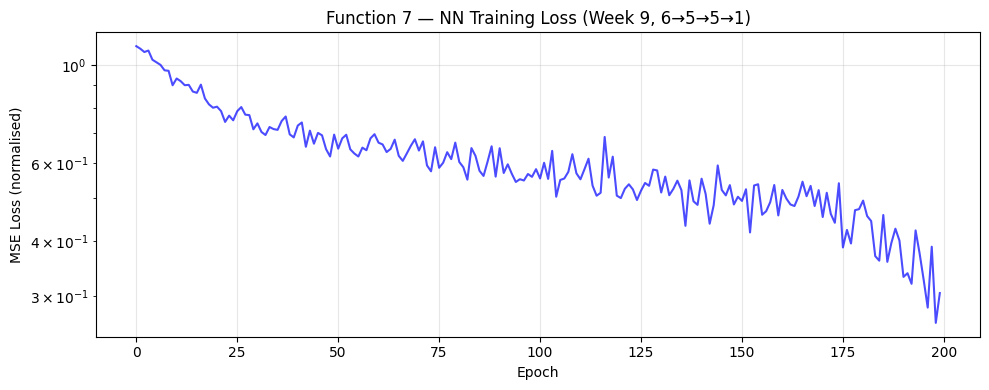


Training R²: 0.764412


In [16]:
# ── Define & Train Neural Network ──
class SurrogateNN(nn.Module):
    """Compact NN surrogate: 6→5→5→1 (71 parameters)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SurrogateNN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: 6→5→5→1, Parameters: {n_params}")

# Train with Adam, MSE loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (normalised)')
plt.title('Function 7 — NN Training Loss (Week 9, 6→5→5→1)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

# Training R² on original scale
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_raw - train_pred_orig)**2) / np.sum((y_raw - y_raw.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

In [17]:
# ── MC Dropout EI + Interior Penalty ──

# 1. Generate random candidates in [0,1]⁶
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, DIM))

# 2. Normalise candidates and run MC Dropout forward passes
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model.train()  # enable dropout for MC sampling
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

# 3. Un-normalise predictions to original scale
mc_preds_orig = np.array(mc_predictions) * y_std + y_mean  # (50, 20000)
mu = mc_preds_orig.mean(axis=0)     # (20000,) - MC mean
sigma = mc_preds_orig.std(axis=0)   # (20000,) - MC std

# 4. Compute EI via sample-then-average (non-parametric)
y_best = y_raw.max()
ei = np.mean(np.maximum(mc_preds_orig - y_best, 0), axis=0)  # (20000,)

# 5. Compute interior penalty weight
#    w(x) = FLOOR + (1-FLOOR) · ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * candidates) ** (2 * STEEPNESS), axis=1
)  # (20000,)

assert interior_weight.min() >= FLOOR - 1e-10, f"Min weight {interior_weight.min()} < FLOOR"
assert interior_weight.max() <= 1.0 + 1e-10, f"Max weight {interior_weight.max()} > 1.0"

# 6. Multiplicative penalty: penalised_EI = EI × w(x)
#    Works because all F7 outputs are positive → EI ≥ 0
penalised_ei = ei * interior_weight

# 7. Select best candidate (with fallback)
raw_best_idx = np.argmax(ei)
if penalised_ei.max() > 0:
    best_idx = np.argmax(penalised_ei)
else:
    # Fallback: all EI = 0 → pick most interior candidate for exploration
    best_idx = np.argmax(interior_weight)
    print("⚠ All EI = 0 — fallback to most interior candidate")

best_point = candidates[best_idx]
assert np.all(best_point >= 0) and np.all(best_point <= 1), "best_point out of [0,1]"

# 8. Report results
penalty_changed = (best_idx != raw_best_idx)
print("=== MC Dropout EI + Interior Penalty (Week 9) ===")
print(f"  y_best (observed)    = {y_best:.6f}")
print(f"  EI range             = [{ei.min():.6f}, {ei.max():.6f}]")
print(f"  Penalty weight range = [{interior_weight.min():.4f}, {interior_weight.max():.4f}]")
print(f"  Penalised EI range   = [{penalised_ei.min():.6f}, {penalised_ei.max():.6f}]")
print(f"\n  Raw EI best:        idx={raw_best_idx}, EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}")
print(f"  Penalised EI best:  idx={best_idx}, EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}")
print(f"  Predicted mean (μ)  = {mu[best_idx]:.6f}")
print(f"  Predicted std (σ)   = {sigma[best_idx]:.6f}")
print(f"\n  Penalty changed selection: {'YES ✓' if penalty_changed else 'NO — same candidate'}")
print(f"  Best point: {best_point}")

⚠ All EI = 0 — fallback to most interior candidate
=== MC Dropout EI + Interior Penalty (Week 9) ===
  y_best (observed)    = 2.304991
  EI range             = [0.000000, 0.000000]
  Penalty weight range = [0.0342, 0.9835]
  Penalised EI range   = [0.000000, 0.000000]

  Raw EI best:        idx=0, EI=0.000000, w=0.4732
  Penalised EI best:  idx=6239, EI=0.000000, w=0.9835
  Predicted mean (μ)  = 0.421767
  Predicted std (σ)   = 0.113213

  Penalty changed selection: YES ✓
  Best point: [0.50505163 0.56448574 0.45259003 0.45803555 0.58965013 0.52635351]


In [18]:
# ── Feature Importance via Input Gradients ──
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()

top2 = np.argsort(grad_importance)[-2:]  # indices of two most important dims

print("=== Feature Importance (Input Gradient Magnitude, Week 9) ===")
for i, imp in enumerate(grad_importance):
    bar = '█' * int(imp * 40)
    marker = ' ◄ top-2' if i in top2 else ''
    print(f"  x{i} ({hyperparam_names[i]:>14s}): {imp:.4f} {bar}{marker}")

=== Feature Importance (Input Gradient Magnitude, Week 9) ===
  x0 ( learning_rate): 0.2798 ███████████ ◄ top-2
  x1 (  reg_strength): 0.0679 ██
  x2 (      n_layers): 0.1605 ██████
  x3 (       dropout): 0.1734 ██████ ◄ top-2
  x4 (    batch_size): 0.1619 ██████
  x5 (     optimizer): 0.1564 ██████


Top-2 dims: x3 (dropout), x0 (learning_rate)
Fixed: x1=0.2618, x2=0.6235, x4=0.3524, x5=0.6873


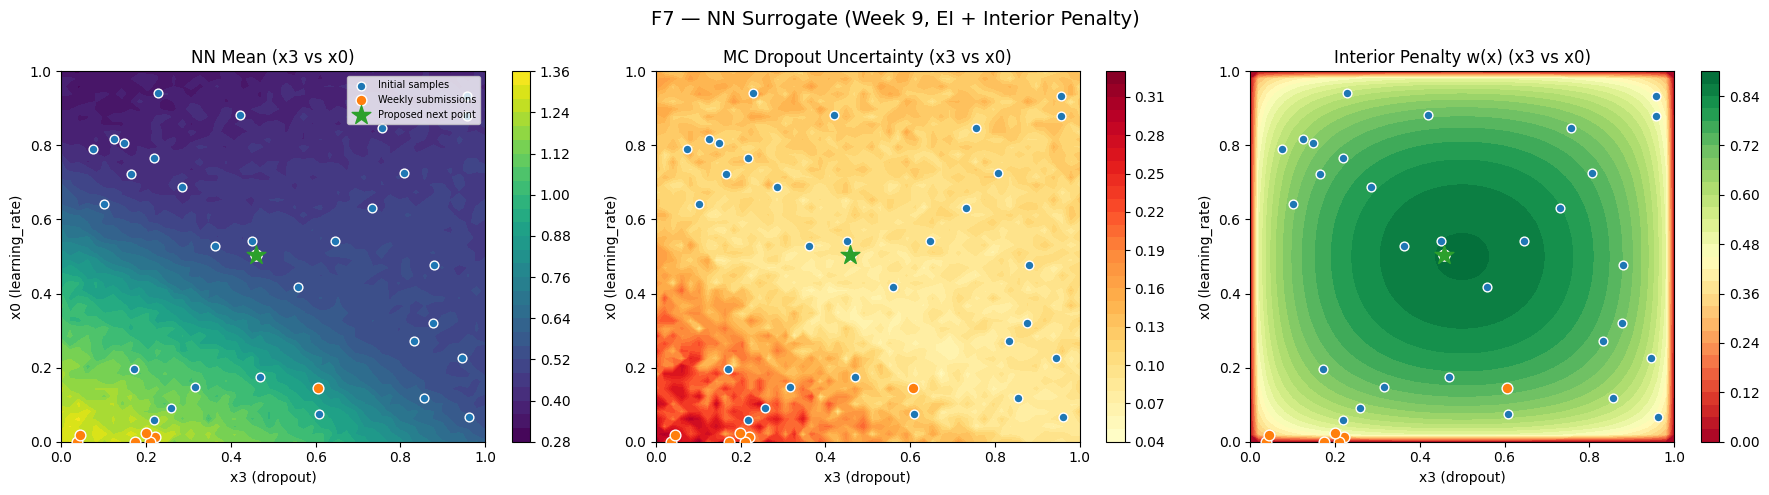

In [19]:
# ── 3-Panel Visualisation (NN Mean, MC Uncertainty, Interior Penalty) ──
fixed_dims = [d for d in range(DIM) if d not in top2]
best_obs = X_raw[y_raw.argmax()]

print(f"Top-2 dims: x{top2[0]} ({hyperparam_names[top2[0]]}), x{top2[1]} ({hyperparam_names[top2[1]]})")
print(f"Fixed: " + ", ".join(f"x{d}={best_obs[d]:.4f}" for d in fixed_dims))

# Build grid on top-2 dimensions
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((GRID_RES * GRID_RES, DIM))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

# MC Dropout predictions on grid
grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # enable dropout
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(GRID_RES, GRID_RES)
grid_sigma = grid_mc.std(axis=0).reshape(GRID_RES, GRID_RES)

# Interior penalty on grid
grid_penalty = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * grid_pts) ** (2 * STEEPNESS), axis=1
).reshape(GRID_RES, GRID_RES)

# Plot 3 panels — three-colour scheme
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax in axes:
    # Initial samples (blue)
    ax.scatter(X_initial[:, top2[0]], X_initial[:, top2[1]],
               c='tab:blue', edgecolors='white', s=40, zorder=5, label='Initial samples')
    # Weekly submissions (orange)
    ax.scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]],
               c='tab:orange', edgecolors='white', s=60, zorder=5, label='Weekly submissions')
    # Proposed next point (green star)
    ax.scatter(best_point[top2[0]], best_point[top2[1]],
               c='tab:green', marker='*', s=200, zorder=6, label='Proposed next point')

# Panel 1: NN Mean
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[0].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c1, ax=axes[0])

# Panel 2: MC Dropout Uncertainty
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[1].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Interior Penalty Heatmap
c3 = axes[2].contourf(G0, G1, grid_penalty, levels=30, cmap='RdYlGn')
axes[2].set_title(f"Interior Penalty w(x) (x{top2[0]} vs x{top2[1]})")
axes[2].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[2].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c3, ax=axes[2])

axes[0].legend(loc='upper right', fontsize=7)
plt.suptitle("F7 — NN Surrogate (Week 9, EI + Interior Penalty)", fontsize=14)
plt.tight_layout()
plt.show()

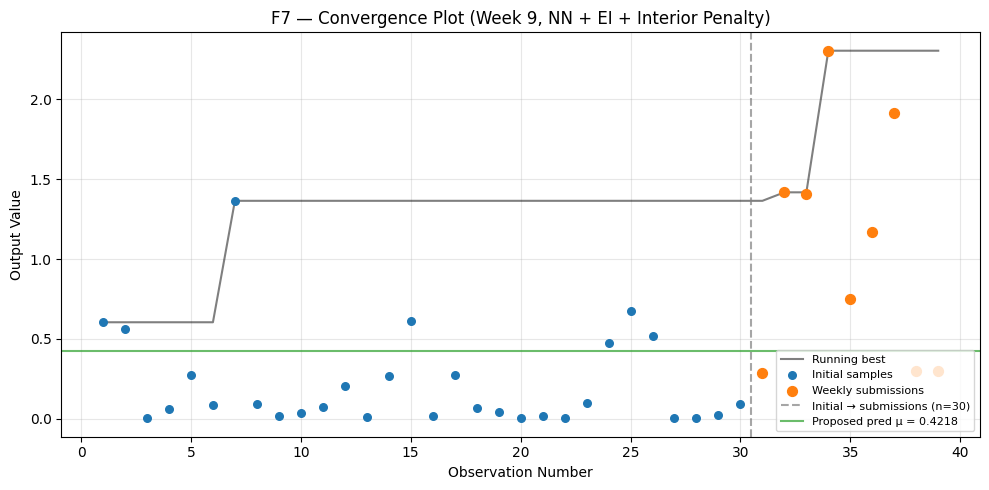

Best initial (sample 1–30): 1.364968
Best overall (sample 1–39): 2.304991
IP-selected predicted mean: 0.421767
Penalty changed selection: YES ✓


In [20]:
# ── Convergence Plot (three-colour) ──
running_best = np.maximum.accumulate(y_raw)
indices = np.arange(1, len(y_raw) + 1)

plt.figure(figsize=(10, 5))
plt.plot(indices, running_best, 'k-', linewidth=1.5, alpha=0.5, label='Running best')

# Initial observations (blue)
plt.scatter(indices[:N_INITIAL], y_raw[:N_INITIAL],
            c='tab:blue', s=30, zorder=4, label='Initial samples')
# Submission observations (orange)
plt.scatter(indices[N_INITIAL:], y_raw[N_INITIAL:],
            c='tab:orange', s=50, zorder=4, label='Weekly submissions')

# Boundary between initial and submissions
plt.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
            label=f'Initial → submissions (n={N_INITIAL})')

# IP-selected candidate predicted mean
plt.axhline(y=mu[best_idx], color='tab:green', linestyle='-', alpha=0.7,
            label=f'Proposed pred μ = {mu[best_idx]:.4f}')

plt.xlabel("Observation Number")
plt.ylabel("Output Value")
plt.title("F7 — Convergence Plot (Week 9, NN + EI + Interior Penalty)")
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best initial (sample 1–{N_INITIAL}): {y_initial.max():.6f}")
print(f"Best overall (sample 1–{N_TOTAL}): {y_raw.max():.6f}")
print(f"IP-selected predicted mean: {mu[best_idx]:.6f}")
print(f"Penalty changed selection: {'YES ✓' if penalty_changed else 'NO'}")

In [21]:
# ── Submission Query ──
submission_point = np.clip(best_point, 0.0, 0.999999)
submission_query = "-".join(f"{v:.6f}" for v in submission_point)

print("=" * 60)
print("WEEK 9 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n  {submission_query}\n")
print("=" * 60)

# Format validation
parts = submission_query.split("-")
assert len(parts) == N_DIMS, f"Expected {N_DIMS} dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
print("✓ Submission format validated (6 dims, all in [0, 0.999999])")

# Hyperparameter metadata
print(f"\n── Hyperparameters ──")
print(f"  Architecture: 6→5→5→1 ({n_params} params)")
print(f"  Learning rate: {LEARNING_RATE}, Dropout: {DROPOUT}, Epochs: {EPOCHS}")
print(f"  MC samples: {MC_SAMPLES}, Candidates: {N_CANDIDATES:,}")
print(f"  STEEPNESS: {STEEPNESS}, FLOOR: {FLOOR}")
print(f"  Training R²: {train_r2:.6f}")

# Penalty effect
print(f"\n── Penalty Effect ──")
print(f"  Raw EI best:       [{'-'.join(f'{v:.6f}' for v in candidates[raw_best_idx])}]")
print(f"    EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}, penalised={penalised_ei[raw_best_idx]:.6f}")
print(f"  IP-selected:       [{'-'.join(f'{v:.6f}' for v in best_point)}]")
print(f"    EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}, penalised={penalised_ei[best_idx]:.6f}")
print(f"  Selection changed: {'YES ✓' if penalty_changed else 'NO'}")

# Per-dimension breakdown
print(f"\n── Per-Dimension Coordinates ──")
for i, (name, val) in enumerate(zip(hyperparam_names, submission_point)):
    print(f"  x{i} ({name:>14s}): {val:.6f}")

WEEK 9 SUBMISSION QUERY FOR FUNCTION 7

  0.505052-0.564486-0.452590-0.458036-0.589650-0.526354

✓ Submission format validated (6 dims, all in [0, 0.999999])

── Hyperparameters ──
  Architecture: 6→5→5→1 (71 params)
  Learning rate: 0.005, Dropout: 0.1, Epochs: 200
  MC samples: 50, Candidates: 20,000
  STEEPNESS: 0.1, FLOOR: 0.01
  Training R²: 0.764412

── Penalty Effect ──
  Raw EI best:       [0.374540-0.950714-0.731994-0.598658-0.156019-0.155995]
    EI=0.000000, w=0.4732, penalised=0.000000
  IP-selected:       [0.505052-0.564486-0.452590-0.458036-0.589650-0.526354]
    EI=0.000000, w=0.9835, penalised=0.000000
  Selection changed: YES ✓

── Per-Dimension Coordinates ──
  x0 ( learning_rate): 0.505052
  x1 (  reg_strength): 0.564486
  x2 (      n_layers): 0.452590
  x3 (       dropout): 0.458036
  x4 (    batch_size): 0.589650
  x5 (     optimizer): 0.526354


### Performance Evaluation — Convergence Metrics & Stalling Detection

In [22]:
# ── Convergence Metrics & Stalling Detection ──
best_initial = y_initial.max()
best_final = y_raw.max()
improvement = best_final - best_initial

# Relative improvement
if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

# Per-submission trajectory
submission_bests = [y_raw[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)]
per_submission_delta = []
new_best_flags = []
for k in range(N_SUBMISSIONS):
    prev = submission_bests[k - 1] if k > 0 else best_initial
    delta = submission_bests[k] - prev
    per_submission_delta.append(delta)
    new_best_flags.append(delta > 0)

# Tail-only consecutive no-improvement (count backwards from most recent)
tail_no_improve = 0
for imp in reversed(per_submission_delta):
    if imp <= 0:
        tail_no_improve += 1
    else:
        break

stalling_consecutive = tail_no_improve >= STALLING_CONSECUTIVE_THRESHOLD
stalling_relative = relative_improvement < STALLING_RELATIVE_THRESHOLD
stalling_flag = stalling_consecutive or stalling_relative

print("=" * 60)
print("CONVERGENCE METRICS")
print("=" * 60)
print(f"  Best initial:         {best_initial:.6f}")
print(f"  Best final:           {best_final:.6f}")
print(f"  Absolute improvement: {improvement:.6f}")
print(f"  Relative improvement: {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"\n  Per-submission deltas:")
for k in range(N_SUBMISSIONS):
    week = k + 3  # submissions start at Week 3
    marker = "★" if new_best_flags[k] else " "
    print(f"    Week {week}: Δ = {per_submission_delta[k]:+.6f}  best = {submission_bests[k]:.6f}  {marker}")
print(f"\n  Trailing no-improvement streak: {tail_no_improve}")
print(f"  Stalling (consecutive ≥ {STALLING_CONSECUTIVE_THRESHOLD}): {'YES ⚠' if stalling_consecutive else 'NO ✓'}")
print(f"  Stalling (relative < {STALLING_RELATIVE_THRESHOLD}):  {'YES ⚠' if stalling_relative else 'NO ✓'}")
print(f"  Overall stalling:              {'YES ⚠' if stalling_flag else 'NO ✓'}")

CONVERGENCE METRICS
  Best initial:         1.364968
  Best final:           2.304991
  Absolute improvement: 0.940023
  Relative improvement: 0.6887 (68.9%)

  Per-submission deltas:
    Week 3: Δ = +0.000000  best = 1.364968   
    Week 4: Δ = +0.053193  best = 1.418161  ★
    Week 5: Δ = +0.000000  best = 1.418161   
    Week 6: Δ = +0.886830  best = 2.304991  ★
    Week 7: Δ = +0.000000  best = 2.304991   
    Week 8: Δ = +0.000000  best = 2.304991   
    Week 9: Δ = +0.000000  best = 2.304991   
    Week 10: Δ = +0.000000  best = 2.304991   
    Week 11: Δ = +0.000000  best = 2.304991   

  Trailing no-improvement streak: 5
  Stalling (consecutive ≥ 3): YES ⚠
  Stalling (relative < 0.05):  NO ✓
  Overall stalling:              YES ⚠


### Performance Evaluation — Exploration Spread

In [23]:
# ── Exploration Spread ──
EXPECTED_UNIFORM = 0.88  # expected mean pairwise distance for 6D uniform [0,1]^6

dists = pdist(X_submissions)
mean_pairwise = dists.mean()

dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

print("=" * 60)
print("EXPLORATION SPREAD (submissions only)")
print("=" * 60)
print(f"  Submission points:      {len(X_submissions)}")
print(f"  Dimensions:             {N_DIMS}")
print(f"  Mean pairwise distance: {mean_pairwise:.4f}  (uniform ≈ {EXPECTED_UNIFORM})")
print(f"  Max NN distance:        {max_nn_dist:.4f}")
print(f"  Min NN distance:        {min_nn_dist:.4f}")

ratio = mean_pairwise / EXPECTED_UNIFORM
if ratio < 0.5:
    spread_status = "CLUSTERED ⚠ — submissions concentrated in small region"
elif ratio < 0.8:
    spread_status = "MODERATE — some clustering, room for more exploration"
else:
    spread_status = "WELL-SPREAD ✓ — good coverage of search space"
print(f"  Spread ratio:           {ratio:.2f} — {spread_status}")

EXPLORATION SPREAD (submissions only)
  Submission points:      9
  Dimensions:             6
  Mean pairwise distance: 0.6324  (uniform ≈ 0.88)
  Max NN distance:        0.7874
  Min NN distance:        0.0000
  Spread ratio:           0.72 — MODERATE — some clustering, room for more exploration


### Performance Evaluation — Leave-One-Out Surrogate Error (NN)

In [24]:
# ── LOO Surrogate Error (NN retrain, 9 folds over submissions) ──
loo_predictions = []
loo_actuals = []

for fold in range(N_SUBMISSIONS):
    hold_idx = N_INITIAL + fold  # index into full dataset

    # Build LOO dataset: all points except held-out
    mask = np.ones(N_TOTAL, dtype=bool)
    mask[hold_idx] = False
    X_loo = X_raw[mask]
    y_loo = y_raw[mask]

    # Recompute z-score normalisation per fold
    X_m, X_s = X_loo.mean(axis=0), X_loo.std(axis=0) + 1e-8
    y_m, y_s = y_loo.mean(), y_loo.std() + 1e-8

    X_loo_norm = (X_loo - X_m) / X_s
    y_loo_norm = (y_loo - y_m) / y_s

    X_loo_t = torch.tensor(X_loo_norm, dtype=torch.float32)
    y_loo_t = torch.tensor(y_loo_norm, dtype=torch.float32).unsqueeze(1)

    # Retrain NN from scratch with fixed seed
    torch.manual_seed(42)
    loo_model = SurrogateNN()
    loo_opt = optim.Adam(loo_model.parameters(), lr=LEARNING_RATE)
    loo_crit = nn.MSELoss()

    loo_model.train()
    for epoch in range(EPOCHS):
        loo_opt.zero_grad()
        pred = loo_model(X_loo_t)
        loss = loo_crit(pred, y_loo_t)
        loss.backward()
        loo_opt.step()

    # Predict on held-out point — single forward pass (NO MC dropout)
    loo_model.eval()
    x_held = X_raw[hold_idx:hold_idx+1]
    x_held_norm = (x_held - X_m) / X_s
    x_held_t = torch.tensor(x_held_norm, dtype=torch.float32)

    with torch.no_grad():
        pred_norm = loo_model(x_held_t).item()

    # De-normalise prediction back to original scale
    pred_orig = pred_norm * y_s + y_m
    actual = y_raw[hold_idx]

    loo_predictions.append(pred_orig)
    loo_actuals.append(actual)

loo_predictions = np.array(loo_predictions)
loo_actuals = np.array(loo_actuals)
loo_errors = loo_predictions - loo_actuals
loo_mae = np.mean(np.abs(loo_errors))
loo_rmse = np.sqrt(np.mean(loo_errors**2))

print("=" * 60)
print("LOO SURROGATE ERROR (NN retrain, 9 folds)")
print("=" * 60)
print(f"  MAE:  {loo_mae:.6f}")
print(f"  RMSE: {loo_rmse:.6f}")
print(f"\n  Per-fold results:")
print(f"  {'Fold':>4s}  {'Actual':>10s}  {'Predicted':>10s}  {'Error':>10s}  {'|Error|':>10s}")
for i in range(N_SUBMISSIONS):
    print(f"  {i+1:4d}  {loo_actuals[i]:10.6f}  {loo_predictions[i]:10.6f}  "
          f"{loo_errors[i]:+10.6f}  {abs(loo_errors[i]):10.6f}")
print(f"\n  Note: LOO on {N_SUBMISSIONS} submission points only.")
print(f"  NN retrained 200 epochs per fold with torch.manual_seed(42).")
print(f"  Single forward pass (no MC dropout) for prediction.")

LOO SURROGATE ERROR (NN retrain, 9 folds)
  MAE:  0.342468
  RMSE: 0.500678

  Per-fold results:
  Fold      Actual   Predicted       Error     |Error|
     1    0.285444    0.451145   +0.165701    0.165701
     2    1.418161    1.236419   -0.181743    0.181743
     3    1.404908    1.319846   -0.085062    0.085062
     4    2.304991    1.201898   -1.103094    1.103094
     5    0.747724    0.951417   +0.203693    0.203693
     6    1.172152    0.932557   -0.239595    0.239595
     7    1.913486    0.987798   -0.925688    0.925688
     8    0.300001    0.388820   +0.088818    0.088818
     9    0.300001    0.388820   +0.088818    0.088818

  Note: LOO on 9 submission points only.
  NN retrained 200 epochs per fold with torch.manual_seed(42).
  Single forward pass (no MC dropout) for prediction.


### Performance Evaluation — Interpretation & Strategy

**Convergence**: Check the stalling flag above. If stalling is detected (consecutive ≥ 3 or relative < 5%), the NN surrogate may lack the uncertainty calibration needed for effective BO exploration.

**Exploration Spread**: Compare `mean_pairwise_distance` to ~0.88 (expected for 6D uniform). Values significantly below indicate the MC Dropout EI is exploiting rather than exploring.

**Surrogate Accuracy**: LOO MAE and RMSE above indicate NN prediction quality on held-out submissions. NNs with 71 parameters on 38 training points are prone to high variance.

**Strategy Recommendations** (if stalling or poor accuracy):
1. **Switch to SingleTaskGP with Matérn 2.5 kernel** — GP provides calibrated uncertainty estimates; NN dropout uncertainty is known to be poorly calibrated, which undermines EI decisions.
2. **Increase MC dropout samples from 50 to 200** — if keeping the NN, more MC passes improve uncertainty estimates and EI stability.
3. **Widen network to 6→10→10→1** — more capacity may improve fit quality, but watch for overfitting with only 39 samples.